In [1]:
import datetime
import sys
# path为tools的上层文件夹
sys.path.append('D:\milimili')
import numpy as np
import pandas as pd
from configs import TE_app_token
from tools.数数查询 import get_sqldata
token=TE_app_token['Doomsday Vanguard']

In [52]:
sql="""
select * from 

(select "#user_id","current_power","tmp_rolenum","max_chapter_id","current_level","total_pay_amount"
from ta.v_user_33 
where "total_pay_amount" > 100) c

left join (
select * from 
(
select "#user_id" as ng,max("#event_time") as time1
from ta.v_event_33  e
where "#event_name" = 'In_appPurchases_BuySuccess'
and EXISTS (select "#user_id" from  ta.v_user_33  u 
where "total_pay_amount" > 100 
and e."#user_id"  = u."#user_id")
and "$part_date" between '2023-09-01' and '2024-01-24'
group by "#user_id"
) a 
left join 
(
select "#user_id" as chuangguan,"#event_time" as time2,"level_id","if_clearance"
from ta.v_event_33 
where "#event_name" = 'Game_Level_Finish'
-- and "if_clearance"= FALSE 
and "$part_date" between '2023-09-01' and '2024-01-24'
) b 
on a. ng= b.chuangguan
where a.time1 < b.time2 ) d  
on c."#user_id" = d.ng

"""

In [53]:
df_ls=get_sqldata(token,sql)

In [54]:
df_ls.columns=['id','战斗力','角色','关卡','等级','金额','ngid','最后一次内购时间','cgid','闯关时间','闯关关卡','是否通关']

In [57]:
df_ls['金额'].astype('float').max()

5571.409950017928

In [42]:
df_ls.groupby(by='关卡',as_index=False)['id'].nunique().sort_values(by='id',ascending=False).head(50)

,关卡,id
18,20,197
19,21,141
13,16,133
24,26,127
16,19,119
14,17,119
9,13,104
11,14,100
30,31,97
21,23,97


In [58]:
# 战斗力和充值金额关系
df2=df_ls[['id','战斗力','金额']]


In [63]:
df2['金额']=df2['金额'].astype('float')

C:\Users\admin\AppData\Local\Temp\ipykernel_14928\971300871.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['金额']=df2['金额'].astype('float')


In [64]:
df2.drop_duplicates(subset=['id','战斗力','金额'],keep='first',inplace=True)

C:\Users\admin\AppData\Local\Temp\ipykernel_14928\1273495004.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2.drop_duplicates(subset=['id','战斗力','金额'],keep='first',inplace=True)


In [60]:
df2=df2.query('战斗力==战斗力')

In [65]:
df2.sort_values(by='金额',ascending=True,inplace=True)

C:\Users\admin\AppData\Local\Temp\ipykernel_14928\1377168918.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2.sort_values(by='金额',ascending=True,inplace=True)


In [71]:
df2['金额区间']=pd.cut(df2['金额'],# 需要分组的列
       bins=[i for  i in range(100,5700,100)],# 分组的组数或者自定义分组列表
       right=False,# 是否包含右边的值
       labels=[i for  i in range(100,5600,100)],# 显示标签
       include_lowest=True # 是否包含最低值
      )

C:\Users\admin\AppData\Local\Temp\ipykernel_14928\340704588.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['金额区间']=pd.cut(df2['金额'],# 需要分组的列


In [75]:
df2['战斗力']=df2['战斗力'].astype('float')

C:\Users\admin\AppData\Local\Temp\ipykernel_14928\3950951549.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['战斗力']=df2['战斗力'].astype('float')


In [76]:
df3=df2.groupby(by='金额区间',as_index=False)['战斗力'].mean()

In [78]:
df3=df3.query('战斗力==战斗力')

In [79]:
df3

,金额区间,战斗力
0,100,5316.045510
1,200,6650.945865
2,300,7499.989831
3,400,9485.750000
4,500,9942.683673
5,600,10635.300000
6,700,10496.756098
7,800,12723.600000
8,900,13675.083333
9,1000,14132.800000


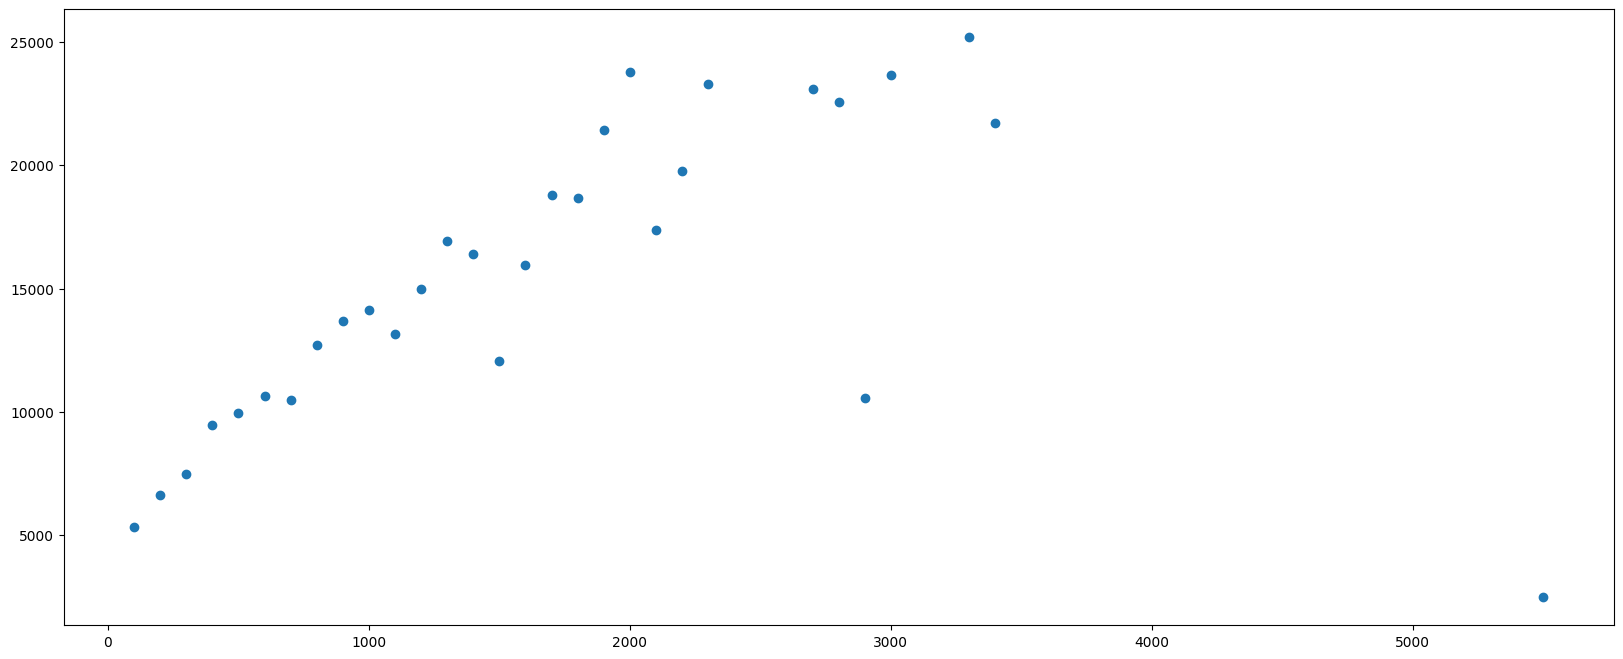

In [80]:
from matplotlib import  pyplot as plt
plt.figure(figsize=(20,8),dpi=100)
plt.scatter(df3['金额区间'],df3['战斗力'])
plt.show()

In [96]:
# 付费后闯关成功和失败的次数
df_cg=df_ls.query('cgid==cgid')

In [97]:
df_cg['闯关成功']=df_cg.apply(lambda x: 1 if x['是否通关']=='true' else 0,axis=1)
df_cg['闯关失败']=df_cg.apply(lambda x: 1 if x['是否通关']=='false' else 0,axis=1)

C:\Users\admin\AppData\Local\Temp\ipykernel_14928\4207692244.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cg['闯关成功']=df_cg.apply(lambda x: 1 if x['是否通关']=='true' else 0,axis=1)
C:\Users\admin\AppData\Local\Temp\ipykernel_14928\4207692244.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cg['闯关失败']=df_cg.apply(lambda x: 1 if x['是否通关']=='false' else 0,axis=1)


In [98]:
df_cg

,id,战斗力,角色,关卡,等级,金额,ngid,最后一次内购时间,cgid,闯关时间,闯关关卡,是否通关,闯关成功,闯关失败
0,1163457863478157312,8194,21,28,77,169.9600048065186,1163457863478157312,2024-01-13 22:19:42.710,1163457863478157312,2024-01-15 05:47:12.012,27,true,1,0
1,1163860394255589376,15059,27,57,82,155.8599979877474,1163860394255589376,2024-01-02 00:33:14.722,1163860394255589376,2024-01-23 15:50:00.836,43,true,1,0
2,1163860394255589376,15059,27,57,82,155.8599979877474,1163860394255589376,2024-01-02 00:33:14.722,1163860394255589376,2024-01-23 15:28:53.791,42,true,1,0
3,1163860394255589376,15059,27,57,82,155.8599979877474,1163860394255589376,2024-01-02 00:33:14.722,1163860394255589376,2024-01-22 21:56:20.283,42,true,1,0
4,1163860394255589376,15059,27,57,82,155.8599979877474,1163860394255589376,2024-01-02 00:33:14.722,1163860394255589376,2024-01-22 21:45:38.746,41,true,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54463,1198364063759867904,3847,19,20,26,199.9499988555909,1198364063759867904,2024-01-22 21:53:36.116,1198364063759867904,2024-01-22 23:14:50.154,6,true,1,0
54464,1198364063759867904,3847,19,20,26,199.9499988555909,1198364063759867904,2024-01-22 21:53:36.116,1198364063759867904,2024-01-22 22:59:04.112,6,true,1,0
54465,1198364063759867904,3847,19,20,26,199.9499988555909,1198364063759867904,2024-01-22 21:53:36.116,1198364063759867904,2024-01-22 22:37:09.845,5,true,1,0
54466,1198364063759867904,3847,19,20,26,199.9499988555909,1198364063759867904,2024-01-22 21:53:36.116,1198364063759867904,2024-01-22 22:19:43.792,5,true,1,0


In [99]:
df_cg.groupby(by='闯关关卡',as_index=False)[['id','闯关成功','闯关失败']].agg({
    'id':'nunique',
    '闯关成功':'sum',
    '闯关失败':'sum'
}).to_excel('大R付费后闯关数据.xlsx',index=False)

In [100]:
df4=df_cg.groupby(by=['闯关关卡','id'],as_index=False)[['闯关成功','闯关失败']].agg({
    '闯关成功':'sum',
    '闯关失败':'sum'
})

In [101]:
df4.query('闯关失败!=0').groupby(by='闯关关卡',as_index=False)['闯关失败'].median().to_excel('闯关失败中位数.xlsx')

In [102]:
df4

,闯关关卡,id,闯关成功,闯关失败
0,1,1152400322560266241,2,0
1,1,1152612683564982272,1,0
2,1,1166700511596916736,2,0
3,1,1167794571082473472,2,0
4,1,1168657742898933760,3,0
...,...,...,...,...
19891,null,1200179849256243204,0,0
19892,null,1200193310606499845,0,0
19893,null,1200247459792564224,0,0
19894,null,1200324934727897088,0,0


In [2]:
sql="""
with tab1 as (
select  a.*,b."page_name",
rank ()over(
PARTITION by a.id1
order by b.time2 desc
) as rank1 
from 
(select "#user_id" as id1,"max_chapter_id","current_level","#country_code","googleshopid","#event_time" as time1
from  ta.v_event_33
WHERE "#event_name" = 'In_appPurchases_BuySuccess'
and "$part_date" between '2023-12-01' and '2024-01-15'
and "#country_code" != 'CN'
and "is_first_pay" = TRUE ) a 
left JOIN 
-- 首次内购前三个页面
(select  "#user_id" as id2,"page_name","#event_time"  as time2 
from  ta.v_event_33
where "#event_name" ='page_enter'
and "$part_date" between '2023-12-01' and '2024-01-15')  b 
on a.id1 = b.id2 
where a.time1 > b.time2)
select * from tab1 where rank1 <= 3
"""

In [3]:
data=get_sqldata(token,sql)

In [6]:
data

,0,1,2,3,4,5,6,7
0,1180514516518055936,3,9,PH,chapter_gift01,2023-12-04 05:08:03.689,商店页面,1
1,1180514516518055936,3,9,PH,chapter_gift01,2023-12-04 05:08:03.689,首充页面,2
2,1180514516518055936,3,9,PH,chapter_gift01,2023-12-04 05:08:03.689,战斗主页面,3
3,1180292243215360000,3,8,JP,no_ad_forever,2023-12-04 01:22:43.328,提示买超级月卡,1
4,1180292243215360000,3,8,JP,no_ad_forever,2023-12-04 01:22:43.328,商店页面,2
...,...,...,...,...,...,...,...,...
86599,1188803222840549376,2,2,JP,chapter_gift01,2023-12-25 12:28:55.217,图鉴,3
86600,1183964322678714368,13,31,JP,chapter_gift01,2023-12-25 12:44:39.125,商店页面,1
86601,1183964322678714368,13,31,JP,chapter_gift01,2023-12-25 12:44:39.125,活动商店-星之召唤,2
86602,1183964322678714368,13,31,JP,chapter_gift01,2023-12-25 12:44:39.125,巡逻页面,3


In [7]:
data.columns=['id','最大关卡','等级','国家','内购商品','time1','内购前页面','rank1']

In [8]:
data_ng=data[['id','最大关卡','等级','内购商品','内购前页面','rank1']]
data_ng['内购商品']=data['内购商品'].str.replace('vanguard_','')

C:\Users\admin\AppData\Local\Temp\ipykernel_14928\3499560660.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_ng['内购商品']=data['内购商品'].str.replace('vanguard_','')


In [9]:
# 内购商品对照表
ng_info = pd.read_excel(r'D:\Desktop\内购对照.xlsx')


In [16]:
data_ng=data_ng.merge(ng_info,how='left',left_on='内购商品',right_on = '谷歌商店ID')

In [11]:
# 内购关卡分布
data_ng.groupby(by='最大关卡',as_index=False)['id'].nunique().sort_values(by='id',ascending=False)

,最大关卡,id
11,2,11048
22,3,5968
32,4,1628
43,6,1589
47,9,1434
46,8,1427
39,5,1230
45,7,1085
48,null,562
4,13,501


In [17]:
data_ng

,id,最大关卡,等级,内购商品,内购前页面,rank1,商品名称,价格,谷歌商店ID
0,1180514516518055936,3,9,chapter_gift01,商店页面,1,第1章礼包,0.99,chapter_gift01
1,1180514516518055936,3,9,chapter_gift01,首充页面,2,第1章礼包,0.99,chapter_gift01
2,1180514516518055936,3,9,chapter_gift01,战斗主页面,3,第1章礼包,0.99,chapter_gift01
3,1180292243215360000,3,8,no_ad_forever,提示买超级月卡,1,永久免广告,12.99,no_ad_forever
4,1180292243215360000,3,8,no_ad_forever,商店页面,2,永久免广告,12.99,no_ad_forever
...,...,...,...,...,...,...,...,...,...
86599,1188803222840549376,2,2,chapter_gift01,图鉴,3,第1章礼包,0.99,chapter_gift01
86600,1183964322678714368,13,31,chapter_gift01,商店页面,1,第1章礼包,0.99,chapter_gift01
86601,1183964322678714368,13,31,chapter_gift01,活动商店-星之召唤,2,第1章礼包,0.99,chapter_gift01
86602,1183964322678714368,13,31,chapter_gift01,巡逻页面,3,第1章礼包,0.99,chapter_gift01


In [18]:
# 内购等级
data_ng.groupby(by='商品名称',as_index=False)['id'].nunique().sort_values(by='id',ascending=False).head(50)

,商品名称,id
58,第1章礼包,19942
46,永久免广告,2905
6,80钻石,1623
61,第2章礼包,629
29,新手装备,483
0,1200钻石,352
2,2500钻石,339
4,500钻石,291
28,成长基金,199
16,凯特碎片礼包,186


In [23]:
# 内购前三次页面组合
page_group = data_ng.groupby(by='id',as_index=False)['内购前页面'].apply(lambda x:x.str.cat(sep=','))

In [25]:
df3=page_group.groupby(by='内购前页面',as_index=False)['id'].nunique().sort_values(by='id',ascending=False)

In [31]:
def func(x):
    lis=str(x['内购前页面']).split(',')
    lis1=lis[::-1]
    str1=''
    for i in lis1:
        if len(str1)==0:
            str1=i
        else :
            str1 =str1 + ' → ' + i 
    return str1

In [32]:
df3['路径']=df3.apply(lambda x:func(x),axis=1)

In [34]:
df3.head(50)

,内购前页面,id,路径
685,"商店页面,首充页面,战斗主页面",4867,战斗主页面 → 首充页面 → 商店页面
559,"商店页面,角色支援,角色界面",2891,角色界面 → 角色支援 → 商店页面
717,"商店页面,首充页面,首充页面",660,首充页面 → 首充页面 → 商店页面
513,"商店页面,装备详细页面,装备详细页面",563,装备详细页面 → 装备详细页面 → 商店页面
679,"商店页面,首充页面,图鉴",563,图鉴 → 首充页面 → 商店页面
682,"商店页面,首充页面,广告特权界面",484,广告特权界面 → 首充页面 → 商店页面
278,"商店页面,战斗主页面,商店页面",469,商店页面 → 战斗主页面 → 商店页面
692,"商店页面,首充页面,月卡页面",460,月卡页面 → 首充页面 → 商店页面
674,"商店页面,首充页面,Follow Us页面",457,Follow Us页面 → 首充页面 → 商店页面
565,"商店页面,角色界面,商店页面",426,商店页面 → 角色界面 → 商店页面


In [19]:
# 购买礼包时前一个页面
df1=data_ng.groupby(by='内购前页面',as_index=False)['id'].nunique()

In [20]:
df1.sort_values(by='id',ascending=False,inplace=True)

In [22]:
df1.head(50)

,内购前页面,id
6,商店页面,24364
70,首充页面,11011
21,战斗主页面,9457
62,角色界面,6163
61,角色支援,3208
30,月卡页面,2585
59,装备页面,1958
2,人才市场界面,1858
27,提示买超级月卡,1752
7,图鉴,1749
